Initial EDA on Telco Churn Dataset

In [ ]:
# !/usr/bin/env python3
# importing libraries
import subprocess
# subprocess.run(["pip", "install", "pandas", "numpy", "matplotlib", "seaborn", "scikit-learn"])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load the dataset
telco_data = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [17]:
# Initial exploration
telco_data.head()
#telco_data.info()
#telco_data.describe()
#telco_data.isnull().sum()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


7043 observations, 21 columns
2 int, 1 float, 18 string
SeniorCitizen is binary 1/0
tenure ranges from 0 to 72, mean of ~32
MonthlyCharges ranges from 18.25 to 118.75 with mean of ~64.76
customerID: string with number and letter combinations
gender: string, Male or Female
Partner: string, Yes or No
Dependents: string, Yes or No
PhoneService: string, Yes or No
MultipleLines: string, Yes No or No Phone Service
InternetService: string
OnlineSecurity: string Yes No 
...

no NA

In [20]:
telco_data['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [23]:
# Convert target to binary
telco_data['Churn_Binary'] = (telco_data['Churn'] == 'Yes').astype(int)

# Churn rate
churn_rate = telco_data['Churn_Binary'].mean()
print(f'Overall churn rate: {churn_rate:.1%}')

Overall churn rate: 26.5%


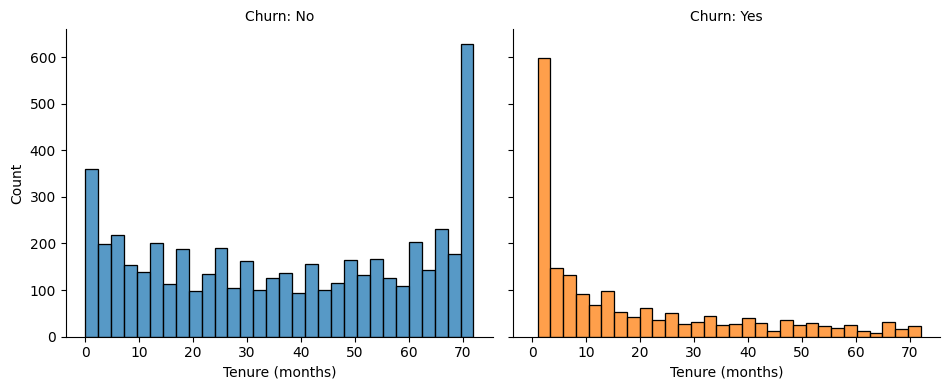

In [27]:
g = sns.FacetGrid(telco_data, col='Churn', hue='Churn', height=4, aspect=1.2)
g.map(sns.histplot, 'tenure', bins=30)
g.set_axis_labels('Tenure (months)', 'Count')
g.set_titles(col_template='Churn: {col_name}')
plt.savefig('../data/plots/tenure_churn.png', dpi=150)
plt.show()

It appears that positive Churn observations are strongly skewed towards shorter tenures. Negative Churn observations gather at the extremes of Tenure values.

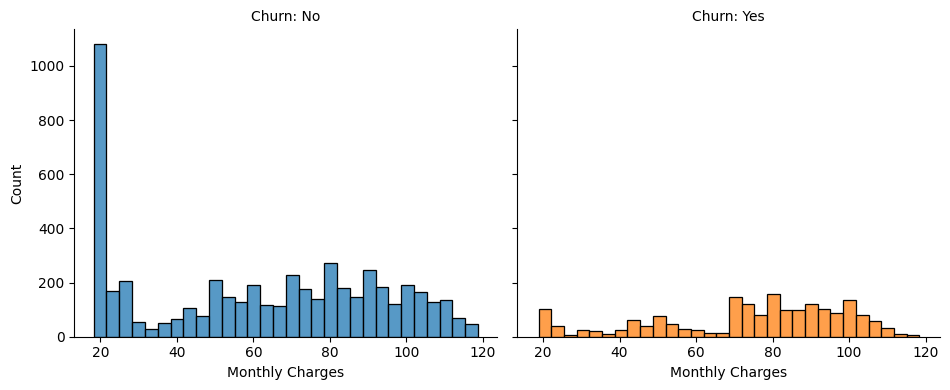

In [28]:
g = sns.FacetGrid(telco_data, col='Churn', hue='Churn', height=4, aspect=1.2)
g.map(sns.histplot, 'MonthlyCharges', bins=30)
g.set_axis_labels('Monthly Charges', 'Count')
g.set_titles(col_template='Churn: {col_name}')
plt.savefig('../data/plots/monthly_charges_churn.png', dpi=150)
plt.show()

I would say in general there is not much to be gained from the shapes of the curves except for that many non Churns have low Monthly Charges.

/var/folders/bh/gx67z70j0d5bn6_xhldx18jh0000gn/T/ipykernel_44278/990061607.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=contract_churn, x='Contract', y='Churn Rate', ax=ax, palette='muted')


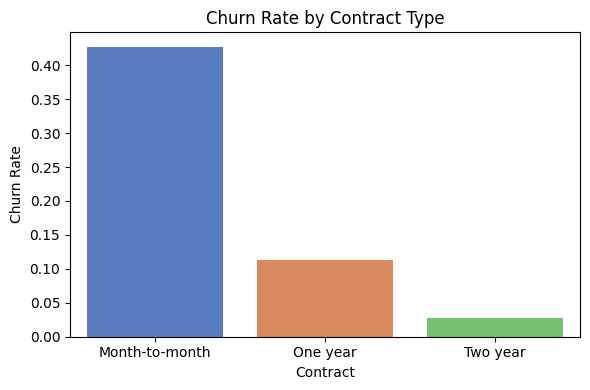

In [29]:
contract_churn = telco_data.groupby('Contract')['Churn_Binary'].mean().reset_index()
contract_churn.columns = ['Contract', 'Churn Rate']

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=contract_churn, x='Contract', y='Churn Rate', ax=ax, palette='muted')
ax.set_title('Churn Rate by Contract Type')
ax.set_ylabel('Churn Rate')
plt.tight_layout()
plt.savefig('../data/plots/contract_churn.png', dpi=150)
plt.show()


The highest Churn rates are for Month-to-month contract observations. It appears that the longer the contract type the less likely the observation is to Churn.

/var/folders/bh/gx67z70j0d5bn6_xhldx18jh0000gn/T/ipykernel_44278/1227110298.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=telco_data, x='Churn', y='MonthlyCharges', ax=ax, palette='muted')


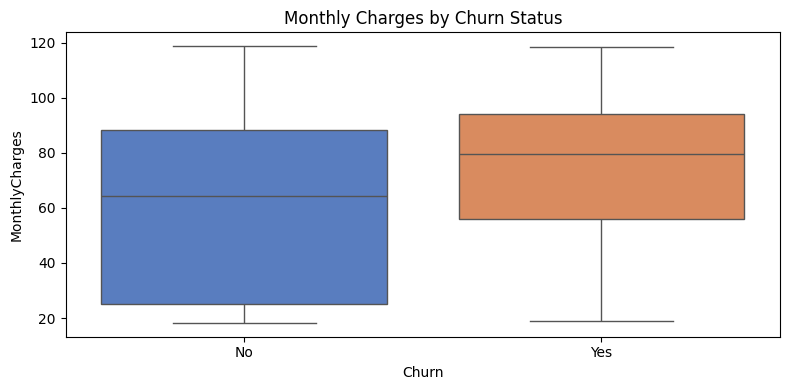

In [30]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=telco_data, x='Churn', y='MonthlyCharges', ax=ax, palette='muted')
ax.set_title('Monthly Charges by Churn Status')
plt.tight_layout()
plt.savefig('../data/plots/charges_churn.png', dpi=150)
plt.show()

It seems that Churns are associated with higher monthly charges on average than non Churns

/var/folders/bh/gx67z70j0d5bn6_xhldx18jh0000gn/T/ipykernel_44278/988495437.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=payment_churn, x='PaymentMethod', y='Churn_Binary', ax=ax, palette='muted')


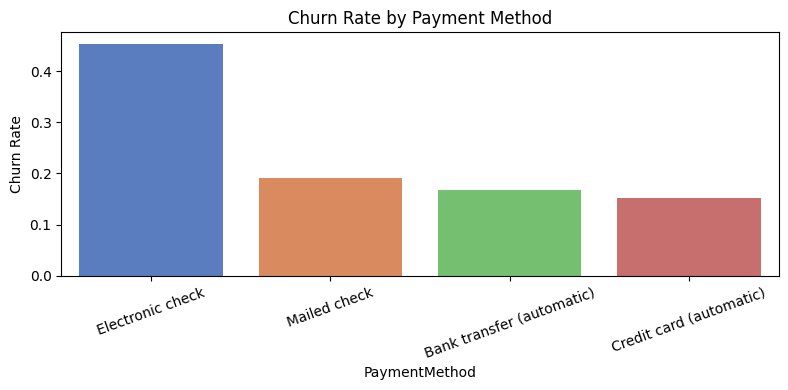

In [31]:
payment_churn = telco_data.groupby('PaymentMethod')['Churn_Binary'].mean().sort_values(ascending=False).reset_index()

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=payment_churn, x='PaymentMethod', y='Churn_Binary', ax=ax, palette='muted')
ax.set_title('Churn Rate by Payment Method')
ax.set_ylabel('Churn Rate')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('../data/plots/payment_churn.png', dpi=150)
plt.show()

Most payment methods are associated with similar Churn rates, except for electronic check which is associated with about double the Churn rate.

/var/folders/bh/gx67z70j0d5bn6_xhldx18jh0000gn/T/ipykernel_44278/310355415.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=telco_data, x='num_services', y='Churn', ax=ax, palette='muted')


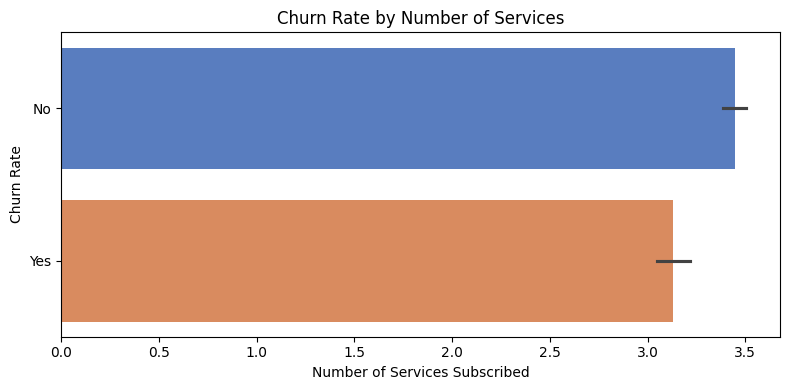

In [32]:
service_cols = ['PhoneService', 'MultipleLines', 'InternetService',
                'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']

# Count services per customer (rough proxy)
telco_data['num_services'] = (telco_data[service_cols] == 'Yes').sum(axis=1)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=telco_data, x='num_services', y='Churn', ax=ax, palette='muted')
ax.set_title('Churn Rate by Number of Services')
ax.set_xlabel('Number of Services Subscribed')
ax.set_ylabel('Churn Rate')
plt.tight_layout()
plt.savefig('../data/plots/services_churn.png', dpi=150)
plt.show()

In [33]:
numeric_cols = telco_data.select_dtypes(include=[np.number]).columns.tolist()
corr = telco_data[numeric_cols].corr()['Churn_Binary'].sort_values(ascending=False)
print(corr)

Churn_Binary      1.000000
MonthlyCharges    0.193356
SeniorCitizen     0.150889
num_services     -0.067264
tenure           -0.352229
Name: Churn_Binary, dtype: float64


It appears that tenure has the highest correlation value with Churning, and is negatively associated (the longer the tenure the lower the probability of churning).

In [34]:
telco_data.to_csv('../data/telco_cleaned.csv', index=False)
print('Saved.')

Saved.
